#### Using the enhanced_nodes.csv and enhanced_edges.csv.

In [2]:
# --- train_SAGE_relational.py (Cell 1) ---
import math
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# -------------------------
# Config
# -------------------------
NODES_FILE = "nodes_enhanced.csv"
EDGES_FILE = "edges_enhanced.csv"
EPOCHS = 50
LR = 7e-4
BATCH_SIZE = 1
DROPOUT = 0.4
HID = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# -------------------------
# Load CSVs
# -------------------------
nodes_df = pd.read_csv(NODES_FILE)
edges_df = pd.read_csv(EDGES_FILE)

need_node_cols = [
    "netlist_file","fault_type","node_id","gate_type","label",
    "total_degree","path_depth","CC0_exact","CC1_exact","CO_exact",
    "dist_to_PO","fanout_norm","gate_delay"
]
for c in need_node_cols:
    if c not in nodes_df.columns:
        raise SystemExit(f"Missing column in nodes CSV: {c}")

need_edge_cols = ["netlist_file","fault_type","src_node","dst_node"]
for c in need_edge_cols:
    if c not in edges_df.columns:
        raise SystemExit(f"Missing column in edges CSV: {c}")

# -------------------------
# Encode class labels
# -------------------------
le = LabelEncoder()
nodes_df["cls"] = le.fit_transform(nodes_df["fault_type"])
class_names = list(le.classes_)
num_classes = len(class_names)
print("Classes:", class_names)

# -------------------------
# Gate type one-hot (logic-only palette)
# -------------------------
logic_gate_whitelist = {"and","nand","nor","not","or","xor","buf","pi","po","PI","PO"}
gate_norm = nodes_df["gate_type"].astype(str).str.lower()
gate_norm = gate_norm.where(gate_norm.isin(logic_gate_whitelist), other="other")
gate_vocab = sorted(gate_norm.unique().tolist())
g2i = {g:i for i,g in enumerate(gate_vocab)}
nodes_df["gate_oh_idx"] = gate_norm.map(g2i)
G = len(gate_vocab)
print("Gate vocab:", gate_vocab)

# -------------------------
# Base numeric features
# -------------------------
base_num_cols = [
    "total_degree","path_depth","CC0_exact","CC1_exact","CO_exact",
    "dist_to_PO","fanout_norm","gate_delay"
]

# -------------------------
# Split by netlist (80/20)
# -------------------------
netlists = nodes_df["netlist_file"].drop_duplicates().values
train_nets, test_nets = train_test_split(netlists, test_size=0.2, random_state=42, shuffle=True)
print(f"Train nets: {len(train_nets)} | Test nets: {len(test_nets)}")

# -------------------------
# Build JOINT graphs per netlist_file
# -------------------------
def build_joint_graphs(nets):
    graphs = []
    for nf in nets:
        nd_sub = nodes_df[nodes_df["netlist_file"] == nf]
        if nd_sub.empty:
            continue

        node_ids = sorted(nd_sub["node_id"].unique().tolist())
        id2idx = {nid:i for i,nid in enumerate(node_ids)}
        N = len(node_ids)

        clean_edges = edges_df[(edges_df["netlist_file"]==nf) & (edges_df["fault_type"]=="clean")]
        if not clean_edges.empty:
            ee = clean_edges
        else:
            ee = edges_df[edges_df["netlist_file"]==nf][["src_node","dst_node"]].drop_duplicates()

        src, dst = [], []
        for _, r in ee.iterrows():
            s, d = r["src_node"], r["dst_node"]
            if s in id2idx and d in id2idx:
                src.append(id2idx[s]); dst.append(id2idx[d])
        edge_index = torch.tensor([src, dst], dtype=torch.long) if len(src) else torch.empty((2,0), dtype=torch.long)

        # gate one-hot from CLEAN if present; else first occurrence
        gt_map = {}
        clean_nodes = nd_sub[nd_sub["fault_type"]=="clean"]
        if not clean_nodes.empty:
            for _, r in clean_nodes.iterrows():
                gt_map[r["node_id"]] = r["gate_type"]
        else:
            first = nd_sub.sort_values("fault_type").drop_duplicates("node_id", keep="first")
            gt_map = dict(zip(first["node_id"], first["gate_type"]))

        gate_oh = np.zeros((N, G), dtype=np.float32)
        for i, nid in enumerate(node_ids):
            gname = str(gt_map.get(nid, "other")).lower()
            gname = gname if gname in g2i else "other"
            gate_oh[i, g2i[gname]] = 1.0

        # numeric base features from CLEAN if available; else first row for that node
        nums = np.zeros((N, len(base_num_cols)), dtype=np.float32)
        for i, nid in enumerate(node_ids):
            rows = nd_sub[nd_sub["node_id"]==nid]
            row = rows[rows["fault_type"]=="clean"]
            if row.empty:
                row = rows.iloc[[0]]
            nums[i,:] = row[base_num_cols].astype(np.float32).values[0]

        # JOINT labels: start CLEAN, overlay faults where label==1
        y = np.full(N, fill_value=class_names.index("clean") if "clean" in class_names else 0, dtype=np.int64)
        for ft in class_names:
            if ft == "clean": continue
            sub = nd_sub[nd_sub["fault_type"]==ft]
            if sub.empty: continue
            faulty_nodes = sub[sub["label"]==1]["node_id"].values
            for nid in faulty_nodes:
                if nid in id2idx:
                    y[id2idx[nid]] = class_names.index(ft)

        data = Data(
            x=torch.from_numpy(np.concatenate([gate_oh, nums], axis=1)),
            edge_index=edge_index,
            y=torch.from_numpy(y),
        )
        data.netlist_file = nf
        graphs.append(data)
    return graphs

train_graphs = build_joint_graphs(train_nets)
test_graphs  = build_joint_graphs(test_nets)
print(f"Built {len(train_graphs)} train + {len(test_graphs)} test joint graphs.")

# -------------------------
# Relational features (same as Hybrid-GAT)
# -------------------------
num_start = G
idx_CC0   = num_start + base_num_cols.index("CC0_exact")
idx_CC1   = num_start + base_num_cols.index("CC1_exact")
idx_CO    = num_start + base_num_cols.index("CO_exact")
idx_path  = num_start + base_num_cols.index("path_depth")
idx_distPO= num_start + base_num_cols.index("dist_to_PO")

def build_adj_lists(edge_index, N):
    src = edge_index[0].cpu().numpy().tolist() if edge_index.numel() else []
    dst = edge_index[1].cpu().numpy().tolist() if edge_index.numel() else []
    out_adj = [[] for _ in range(N)]
    in_adj  = [[] for _ in range(N)]
    for s,d in zip(src,dst):
        out_adj[s].append(d)
        in_adj[d].append(s)
    return in_adj, out_adj

def k_hop_unique_counts(adj, K=3):
    N = len(adj)
    out = np.zeros(N, dtype=np.int32)
    for u in range(N):
        seen = set()
        frontier = [u]
        for _ in range(K):
            nxt = []
            for v in frontier:
                for w in adj[v]:
                    if w not in seen and w != u:
                        seen.add(w)
                        nxt.append(w)
            frontier = nxt
            if not frontier:
                break
        out[u] = len(seen)
    return out

def neighbor_mean(arr, adj):
    N = len(adj)
    out = np.zeros(N, dtype=np.float32)
    for u in range(N):
        neigh = adj[u]
        if neigh:
            out[u] = float(np.mean(arr[neigh]))
        else:
            out[u] = float(arr[u])
    return out

def append_relational_features(data: Data):
    x = data.x.clone().float()
    N = x.size(0)
    in_adj, out_adj = build_adj_lists(data.edge_index, N)

    cc0 = x[:, idx_CC0].cpu().numpy()
    cc1 = x[:, idx_CC1].cpu().numpy()
    co  = x[:, idx_CO ].cpu().numpy()

    # neighbor means
    cc0_in_mean = neighbor_mean(cc0, in_adj);  cc0_out_mean = neighbor_mean(cc0, out_adj)
    cc1_in_mean = neighbor_mean(cc1, in_adj);  cc1_out_mean = neighbor_mean(cc1, out_adj)
    co_in_mean  = neighbor_mean(co,  in_adj);  co_out_mean  = neighbor_mean(co,  out_adj)

    # deltas
    cc0_in_delta  = cc0 - cc0_in_mean;  cc0_out_delta = cc0 - cc0_out_mean
    cc1_in_delta  = cc1 - cc1_in_mean;  cc1_out_delta = cc1 - cc1_out_mean
    co_in_delta   = co  - co_in_mean;   co_out_delta  = co  - co_out_mean

    # k-hop counts
    in_k1  = np.array([len(in_adj[u]) for u in range(N)], dtype=np.int32)
    out_k1 = np.array([len(out_adj[u]) for u in range(N)], dtype=np.int32)
    in_k2  = k_hop_unique_counts(in_adj, K=2);  out_k2 = k_hop_unique_counts(out_adj, K=2)
    in_k3  = k_hop_unique_counts(in_adj, K=3);  out_k3 = k_hop_unique_counts(out_adj, K=3)

    # PI/PO heuristics
    path    = x[:, idx_path].cpu().numpy()
    dist_po = x[:, idx_distPO].cpu().numpy()
    pi_nodes = set(np.where(path == path.min())[0].tolist())
    po_nodes = set(np.where(dist_po == 0)[0].tolist())

    def count_reach(u, targets, adj, K=3):
        seen = set()
        frontier = [u]
        for _ in range(K):
            nxt = []
            for v in frontier:
                for w in adj[v]:
                    if w not in seen:
                        seen.add(w)
                        nxt.append(w)
            frontier = nxt
            if not frontier: break
        return sum(1 for w in seen if w in targets)

    pi_anc3 = np.zeros(N, dtype=np.int32)
    po_des3 = np.zeros(N, dtype=np.int32)
    for u in range(N):
        pi_anc3[u] = count_reach(u, pi_nodes, in_adj,  K=3)
        po_des3[u] = count_reach(u, po_nodes, out_adj, K=3)

    rel_stack = np.stack([
        cc0_in_mean,  cc1_in_mean,  co_in_mean,
        cc0_out_mean, cc1_out_mean, co_out_mean,
        cc0_in_delta, cc1_in_delta, co_in_delta,
        cc0_out_delta,cc1_out_delta,co_out_delta,
        in_k1, out_k1, in_k2, out_k2, in_k3, out_k3,
        pi_anc3, po_des3
    ], axis=1).astype(np.float32)

    data.x = torch.cat([x, torch.from_numpy(rel_stack)], dim=1)
    return data

for lst in (train_graphs, test_graphs):
    for i in range(len(lst)):
        lst[i] = append_relational_features(lst[i])

# -------------------------
# Normalize numeric features (train stats)
# -------------------------
num_slice_start = G
num_dim = train_graphs[0].x.size(1) - G

def fit_norm(graphs):
    X = torch.cat([g.x[:, num_slice_start:] for g in graphs], dim=0).float().cpu().numpy()
    mean = X.mean(axis=0); std = X.std(axis=0) + 1e-6
    return mean.astype(np.float32), std.astype(np.float32)

mu, sigma = fit_norm(train_graphs)

def apply_norm(graphs, mu, sigma):
    for g in graphs:
        nums = g.x[:, num_slice_start:].float().cpu().numpy()
        nums = (nums - mu) / sigma
        g.x[:, num_slice_start:] = torch.from_numpy(nums).float()
    return graphs

train_graphs = apply_norm(train_graphs, mu, sigma)
test_graphs  = apply_norm(test_graphs,  mu, sigma)

print("Final input dim:", train_graphs[0].x.size(1))
print(f"Train graphs: {len(train_graphs)} | Test graphs: {len(test_graphs)}")

# -------------------------
# GraphSAGE Node Classifier
# -------------------------
class NodeSAGE(nn.Module):
    def __init__(self, in_dim, hid=64, out_dim=4, dropout=0.4):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hid)
        self.conv2 = SAGEConv(hid, hid)
        self.ln1 = nn.LayerNorm(hid)
        self.ln2 = nn.LayerNorm(hid)
        self.res1 = nn.Linear(in_dim, hid)
        self.res2 = nn.Linear(hid, hid)
        self.dropout = nn.Dropout(dropout)
        self.cls = nn.Linear(hid, out_dim)

    def forward(self, data):
        x, ei = data.x, data.edge_index
        h1 = self.conv1(x, ei)
        h1 = self.ln1(h1 + self.res1(x))
        h1 = F.relu(h1)
        h1 = self.dropout(h1)

        h2 = self.conv2(h1, ei)
        h2 = self.ln2(h2 + self.res2(h1))
        h2 = F.relu(h2)
        h2 = self.dropout(h2)

        return self.cls(h2)

in_dim = train_graphs[0].x.size(1)
model = NodeSAGE(in_dim=in_dim, hid=HID, out_dim=num_classes, dropout=DROPOUT).to(DEVICE)

# -------------------------
# Loss & Optimizer (same balancing as Hybrid-GAT)
# -------------------------
train_labels_all = np.concatenate([g.y.numpy() for g in train_graphs], axis=0)
cls_counts = np.bincount(train_labels_all, minlength=num_classes).astype(np.float32)
w = (cls_counts.max() / (cls_counts + 1e-6))
w = w / w.sum() * num_classes
weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)
print("Class weights:", weights.cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-4)

rng = np.random.default_rng(12345)

def sample_balanced_idx(y, max_per_fault=512, clean_ratio=1.0):
    y_np = y.cpu().numpy()
    clean_idx = class_names.index("clean") if "clean" in class_names else int(pd.Series(y_np).value_counts().idxmax())

    idxs = []
    fault_total = 0
    for c in range(num_classes):
        if c == clean_idx: 
            continue
        c_idx = np.where(y_np == c)[0]
        if len(c_idx) == 0: 
            continue
        k = min(len(c_idx), max_per_fault)
        sel = rng.choice(c_idx, size=k, replace=False)
        idxs.append(sel)
        fault_total += k

    if fault_total > 0:
        c_idx = np.where(y_np == clean_idx)[0]
        if len(c_idx) > 0:
            k_clean = min(len(c_idx), int(math.ceil(clean_ratio * fault_total)))
            selc = rng.choice(c_idx, size=k_clean, replace=False)
            idxs.append(selc)

    if not idxs:
        sel = rng.choice(np.arange(len(y_np)), size=min(256, len(y_np)), replace=False)
        return torch.from_numpy(np.sort(sel)).long().to(DEVICE)
    return torch.from_numpy(np.unique(np.concatenate(idxs))).long().to(DEVICE)

def train_epoch(graphs):
    model.train()
    loader = DataLoader(graphs, batch_size=1, shuffle=True)
    tot_loss, tot_nodes, corr, seen = 0.0, 0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        logits = model(data)
        sel = sample_balanced_idx(data.y, max_per_fault=512, clean_ratio=1.0)
        loss = criterion(logits[sel], data.y[sel])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tot_loss += loss.item() * sel.numel()
        tot_nodes += sel.numel()

        with torch.no_grad():
            pred = logits[sel].argmax(dim=1)
            corr += int((pred == data.y[sel]).sum().item())
            seen += int(sel.numel())
    return tot_loss/max(1,tot_nodes), corr/max(1,seen)

@torch.no_grad()
def eval_epoch(graphs):
    model.eval()
    loader = DataLoader(graphs, batch_size=1, shuffle=False)
    tot_loss, tot_nodes, corr, seen = 0.0, 0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        logits = model(data)
        loss = criterion(logits, data.y)
        tot_loss += loss.item() * data.num_nodes
        tot_nodes += data.num_nodes
        pred = logits.argmax(dim=1)
        corr += int((pred == data.y).sum().item())
        seen += int(data.num_nodes)
    return tot_loss/max(1,tot_nodes), corr/max(1,seen)

best_val = float('inf')
for ep in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_epoch(train_graphs)
    va_loss, va_acc = eval_epoch(test_graphs)
    if ep % 5 == 0 or ep == 1:
        print(f"[Epoch {ep:02d}] train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} "
              f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")
    if va_loss < best_val:
        best_val = va_loss
        best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}

if 'best_state' in locals():
    model.load_state_dict(best_state)

print("Training done. `model`, `class_names`, `test_graphs`, `DEVICE` are ready.")


Device: cpu
Classes: ['bridging', 'clean', 'glitch', 'stuck_at']
Gate vocab: ['and', 'nand', 'nor', 'not', 'or', 'other', 'xor']
Train nets: 24 | Test nets: 6
Built 24 train + 6 test joint graphs.
Final input dim: 35
Train graphs: 24 | Test graphs: 6
Class weights: [1.3747077  0.00848948 1.3747077  1.2420951 ]
[Epoch 01] train_loss=0.9750 train_acc=0.6263 val_loss=1.0927 val_acc=0.6524
[Epoch 05] train_loss=0.3042 train_acc=0.9206 val_loss=0.8025 val_acc=0.9546
[Epoch 10] train_loss=0.2666 train_acc=0.9301 val_loss=0.7335 val_acc=0.9772
[Epoch 15] train_loss=0.2562 train_acc=0.9392 val_loss=0.6516 val_acc=0.9889
[Epoch 20] train_loss=0.2402 train_acc=0.9525 val_loss=0.6035 val_acc=0.9953
[Epoch 25] train_loss=0.2349 train_acc=0.9551 val_loss=0.3820 val_acc=0.9955
[Epoch 30] train_loss=0.2159 train_acc=0.9570 val_loss=0.2662 val_acc=0.9957
[Epoch 35] train_loss=0.2263 train_acc=0.9597 val_loss=0.3295 val_acc=0.9962
[Epoch 40] train_loss=0.2047 train_acc=0.9611 val_loss=0.1764 val_acc=0.

Test Accuracy: 0.9983

Classification Report:
              precision    recall  f1-score   support

    bridging     0.9977    0.9558    0.9763       452
       clean     1.0000    0.9986    0.9993    120917
      glitch     0.7145    0.9469    0.8145       452
    stuck_at     0.9436    0.9985    0.9703       687

    accuracy                         0.9983    122508
   macro avg     0.9140    0.9750    0.9401    122508
weighted avg     0.9986    0.9983    0.9984    122508


Confusion Matrix:
 [[   432      0     17      3]
 [     0 120749    154     14]
 [     0      0    428     24]
 [     1      0      0    686]]


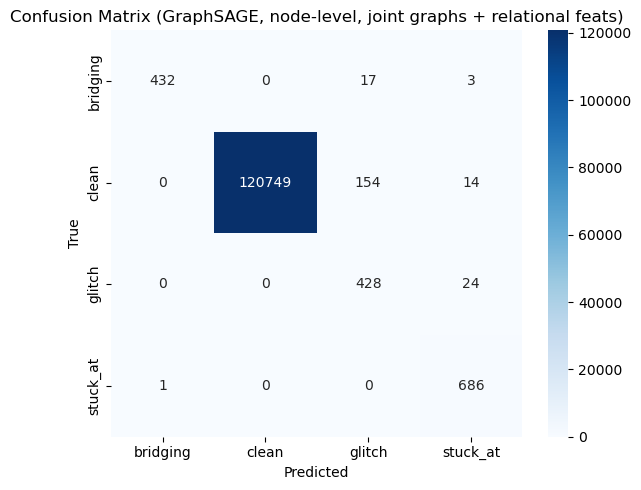

In [3]:
# --- eval_SAGE_relational.py (Cell 2) ---
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader

model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for data in DataLoader(test_graphs, batch_size=1, shuffle=False):
        data = data.to(DEVICE)
        logits = model(data)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(data.y.cpu().numpy().tolist())

acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (GraphSAGE, node-level, joint graphs + relational feats)")
plt.tight_layout()
plt.show()
